# ⚡ Concurrent Agent Workflows with Microsoft Foundry (Python)

## 📋 Parallel Processing Tutorial

This notebook demonstrates a **concurrent workflow** using **Azure AI Foundry Agents** — multiple agents running in parallel (fan-out), with results merged by an aggregator (fan-in).

## 🎯 What We Build

A travel planning pipeline with parallel agents:

```
[User prompt]
    → dispatcher
        ├─ Researcher-Agent  (analyzes attractions in parallel)
        └─ Plan-Agent        (creates itinerary in parallel)
    → aggregator  (merges both outputs)
```

## ⚙️ Prerequisites

### Environment variables (`.env`)
```env
AZURE_AI_PROJECT_ENDPOINT=https://<your-project>.services.ai.azure.com/api/projects/<project-id>
AZURE_AI_MODEL_DEPLOYMENT_NAME=gpt-4.1
```

### Authentication
```bash
az login
```

In [1]:
# ! pip install -r ../../../Installation/requirements.txt -U

In [2]:
import os
from typing import Any

from azure.identity.aio import AzureCliCredential
from dotenv import load_dotenv

from agent_framework.azure import AzureAIAgentsProvider
from agent_framework import AgentExecutor, Message, WorkflowViz
from agent_framework.orchestrations import ConcurrentBuilder

In [3]:
load_dotenv()

True

In [4]:
ResearcherAgentName = "Researcher-Agent"
ResearcherAgentInstructions = (
    "You are a travel researcher. Analyze the destination, list relevant attractions, "
    "and make detailed notes about each attraction."
)

PlanAgentName = "Plan-Agent"
PlanAgentInstructions = (
    "You are a travel planner. Create a detailed day-by-day travel itinerary "
    "based on the destination and travel period provided."
)

Workflow visualization:
flowchart TD
  dispatcher["dispatcher (Start)"];
  researcher_agent["researcher_agent"];
  plan_agent["plan_agent"];
  aggregator["aggregator"];
  fan_in__aggregator__b80af741((fan-in))
  plan_agent --> fan_in__aggregator__b80af741;
  researcher_agent --> fan_in__aggregator__b80af741;
  fan_in__aggregator__b80af741 --> aggregator;
  dispatcher --> researcher_agent;
  dispatcher --> plan_agent;


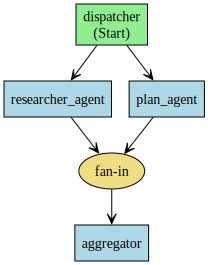

===== Final Aggregated Conversation (messages) =====
------------------------------------------------------------

01 [user]:
Plan a trip to Seattle in December
------------------------------------------------------------

02 [researcher-agent]:
Absolutely! Seattle is magical in December, with festive lights, holiday events, and cozy indoor attractions. Here’s a travel plan with key attractions and detailed notes to help you make the most of your winter trip:

---

## Trip to Seattle in December: Attractions & Detailed Notes

### 1. **Pike Place Market**
- **What:** Iconic public market overlooking Elliott Bay.
- **Why Visit in December:** The market is decked in holiday decor. There are special crafts, local art, tasty seasonal treats (apple cider, holiday pastries), and the famous fish-throwing tradition.
- **Notes:** Try the chowder at Pike Place Chowder; stop by the first Starbucks; bring a rain jacket as it can be wet and chilly.

### 2. **Space Needle**
- **What:** Seattle’s famo

In [5]:
from IPython.display import SVG, display, HTML

research_agent_obj = None
plan_agent_obj = None

async with (
    AzureCliCredential() as credential,
    AzureAIAgentsProvider(credential=credential) as provider,
):
    try:
        # Create agents in Azure AI Foundry
        research_agent_obj = await provider.create_agent(
            name="researcher-agent",
            instructions=ResearcherAgentInstructions,
            model=os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"],
        )
        research_agent = AgentExecutor(research_agent_obj, id="researcher_agent")

        plan_agent_obj = await provider.create_agent(
            name="plan-agent",
            instructions=PlanAgentInstructions,
            model=os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"],
        )
        plan_agent = AgentExecutor(plan_agent_obj, id="plan_agent")

        # Build the concurrent workflow: both agents run in parallel
        workflow = ConcurrentBuilder(participants=[research_agent, plan_agent]).build()

        # Visualize
        print("Workflow visualization:")
        viz = WorkflowViz(workflow)
        print(viz.to_mermaid())
        svg_file = viz.export(format="svg")
        if svg_file and os.path.exists(svg_file):
            try:
                display(SVG(filename=svg_file))
            except Exception:
                with open(svg_file, "r", encoding="utf-8") as f:
                    display(HTML(f.read()))

        # Run both agents concurrently
        events = await workflow.run("Plan a trip to Seattle in December")
        outputs = events.get_outputs()

        if outputs:
            print("===== Final Aggregated Conversation (messages) =====")
            separator = "-" * 60
            for output in outputs:
                messages: list[Message] | Any = output
                for i, msg in enumerate(messages, start=1):
                    name = msg.author_name if msg.author_name else "user"
                    print(f"{separator}\n\n{i:02d} [{name}]:\n{msg.text}")

        print("Final state:", events.get_final_state())

    finally:
        # Clean up agents from Azure AI Foundry
        for agent_obj in [research_agent_obj, plan_agent_obj]:
            if agent_obj is not None:
                try:
                    await provider._agents_client.delete_agent(agent_obj.id)
                except Exception:
                    pass
        print("Agents cleaned up.")